# Week 1 — Vision Transformers, DINOv2 and DESI Legacy Survey galaxies

In this notebook we try to analyse how the DINOv2 model analyses the galaxy images.We start by loading a dataset of real galaxy images. Each image is 160×160 pixels and was taken in four colour filters (g,r,i,z). We look at each filter separately, then combine them into one colour picture. Next we look at the Galaxy Zoo labels -> volunteer votes on whether a galaxy looks SMOOTH, SPIRAL, BARRED and so on. Then we load DINOv2 and pass a galaxy through it once. This model then gives us the CLS and patch tokens. We check the size of each output, draw the grid of squares on the galaxy, and make simple plots of what the model picked up. Finally, we compare many galaxies to see whether similar ones end up close together.

### OVERALL FLOW:
1. Environment Setup
2. Load DESI dataset
3. Dataset Exploration
4. Visualise g/r/i/z
5. Understand Galaxy Zoo labels
6. Load pretrained DINOv2
7. Preprocess image
8. Run inference
9. Extract CLS token
10. Extract patch token
11. Inspect tensor dimensions
12. Visualise patch grid
13. Initial embedding exploration


## 1. Environment setup

In [1]:
!pip install -q datasets transformers scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from datasets import load_dataset
from transformers import AutoModel

np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cpu


## 2. Load the DESI galaxy images

In [3]:
dataset = load_dataset("MultimodalUniverse/legacysurvey", split="train", streaming=True)
dataset = dataset.with_format("numpy")

examples = list(dataset.take(32))
print("Loaded", len(examples), "galaxies")

ex0 = examples[0]
print("Fields in each galaxy:", list(ex0.keys()))
print("Fields inside 'image':", list(ex0["image"].keys()))

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Loaded 32 galaxies
Fields in each galaxy: ['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id']
Fields inside 'image': ['band', 'flux', 'mask', 'ivar', 'psf_fwhm', 'scale']


NOTE : Rather than downloading full data , we stream one at a time.

In [4]:
bands = [str(b) for b in ex0["image"]["band"]]
flux = ex0["image"]["flux"]

print("Bands:", bands)
print("Image shape:", flux.shape)

Bands: ['des-g', 'des-r', 'des-i', 'des-z']
Image shape: (4, 160, 160)


NOTE : Image dimension : (4,160,160)

## 3. Explore the data

In [5]:
rows = []
for ex in examples:
    image = ex["image"]["flux"]
    for i, band in enumerate(bands):
        pixels = image[i]
        rows.append({
            "band": band,
            "min": pixels.min(),
            "median": np.median(pixels),
            "max": pixels.max(),
            "% negative": (pixels < 0).mean() * 100,
        })

pixel_stats = pd.DataFrame(rows).groupby("band").mean()
pixel_stats.round(3)

,min,median,max,% negative
band,,,,
des-g,-0.007,0.000,0.066,46.068
des-i,-0.022,0.001,0.472,45.936
des-r,-0.009,0.000,0.259,45.279
des-z,-0.032,0.001,0.873,46.670


NOTE : Analysis over a set of 32 images -> many values are close to 0 -> empty sky -> some are negative too -> only galaxy light matters -> so the survey has already subtracted the average sky-brightness -> empty sky now sits around 0 and random noise pushes about half of those pixels slightly below 0 (~46% negative in every band).

In [6]:
catalog = pd.DataFrame({
    "flux_g": [float(ex["FLUX_G"]) for ex in examples],
    "flux_r": [float(ex["FLUX_R"]) for ex in examples],
    "flux_z": [float(ex["FLUX_Z"]) for ex in examples],
    "size_arcsec": [float(ex["SHAPE_R"]) for ex in examples],
})

# Convert brightness to magnitude (astronomers' scale: smaller number = brighter)
for band in ["g", "r", "z"]:
    catalog["mag_" + band] = 22.5 - 2.5 * np.log10(catalog["flux_" + band].clip(lower=0.001))

catalog["g_minus_r"] = catalog["mag_g"] - catalog["mag_r"]
catalog.describe().round(2)

,flux_g,flux_r,flux_z,size_arcsec,mag_g,mag_r,mag_z,g_minus_r
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,1.76,5.20,10.80,0.89,22.50,21.21,20.32,1.29
std,2.48,6.25,12.01,0.59,1.12,0.98,0.85,0.37
min,0.07,0.75,3.63,0.22,19.79,19.05,18.24,0.67
25%,0.61,2.06,4.30,0.48,22.03,20.84,20.15,1.13
50%,0.85,2.79,5.39,0.76,22.67,21.39,20.67,1.30
75%,1.54,4.61,8.79,1.04,23.04,21.71,20.92,1.49
max,12.18,24.04,50.50,2.78,25.42,22.81,21.10,2.61


NOTE: Besides the image, each galaxy comes with measurements from the survey's catalogue. Here we take the total brightness in three filters and the galaxy's size (its half-light radius, in arcseconds). We convert brightness into MAGNITUDES, the standard astronomy scale, and compute the colour g − r: a bigger value means a redder galaxy.

Significance :

Blue galaxies are usually still forming young stars-> these are often spirals.
Red galaxies mostly contain old stars->these are often smooth ellipticals.

In our 32 galaxies : median size = 0.76 arcsec (~3 pixels) and average g − r = 1.29 -> small, faint and very red -> most likely distant galaxies (their light is stretched towards red by the expansion of the universe). The pixel stats agree: the galaxies are much brighter in z than in g.

## 4. Visualise the galaxies and their colour bands

In [7]:
def remove_noise(band):
    # Estimate the noise level from the sky, then set anything within the noise to 0
    band = band - np.median(band)
    noise = 1.48 * np.median(np.abs(band))
    return np.clip(band - 2 * noise, 0, None)


def stretch(image):
    # Squash the huge brightness range so the faint outer parts become visible
    image = np.clip(image, 0, None)
    top = np.percentile(image, 99.9) + 1e-6
    return np.clip(np.arcsinh(10 * image / top) / np.arcsinh(10), 0, 1)


def make_color_image(flux):
    # Bands are ordered g, r, i, z. Use z as red, r as green, g as blue.
    rgb = np.stack([remove_noise(flux[3]), remove_noise(flux[1]), remove_noise(flux[0])], axis=-1)
    return stretch(rgb)


color_images = [make_color_image(ex["image"]["flux"]) for ex in examples]
print("Colour image shape:", color_images[0].shape)

Colour image shape: (160, 160, 3)


Defines three small helper functions.

REMOVE_NOISE : measures how much the empty sky wobbles (the noise) and sets everything within ~2x that noise to 0 -> clean black background, only real light remains.

STRETCH : fixes the brightness: the galaxy centre is thousands of times brighter than its edges, so without it we can only see a single white dot. 

MAKE_COLOUR_IMAGE :  builds one normal colour picture from three of the filters (z → red, r → green, g → blue). The i band is left out because a colour picture only has 3 channels. -> DINOv2 needs rgb channels.

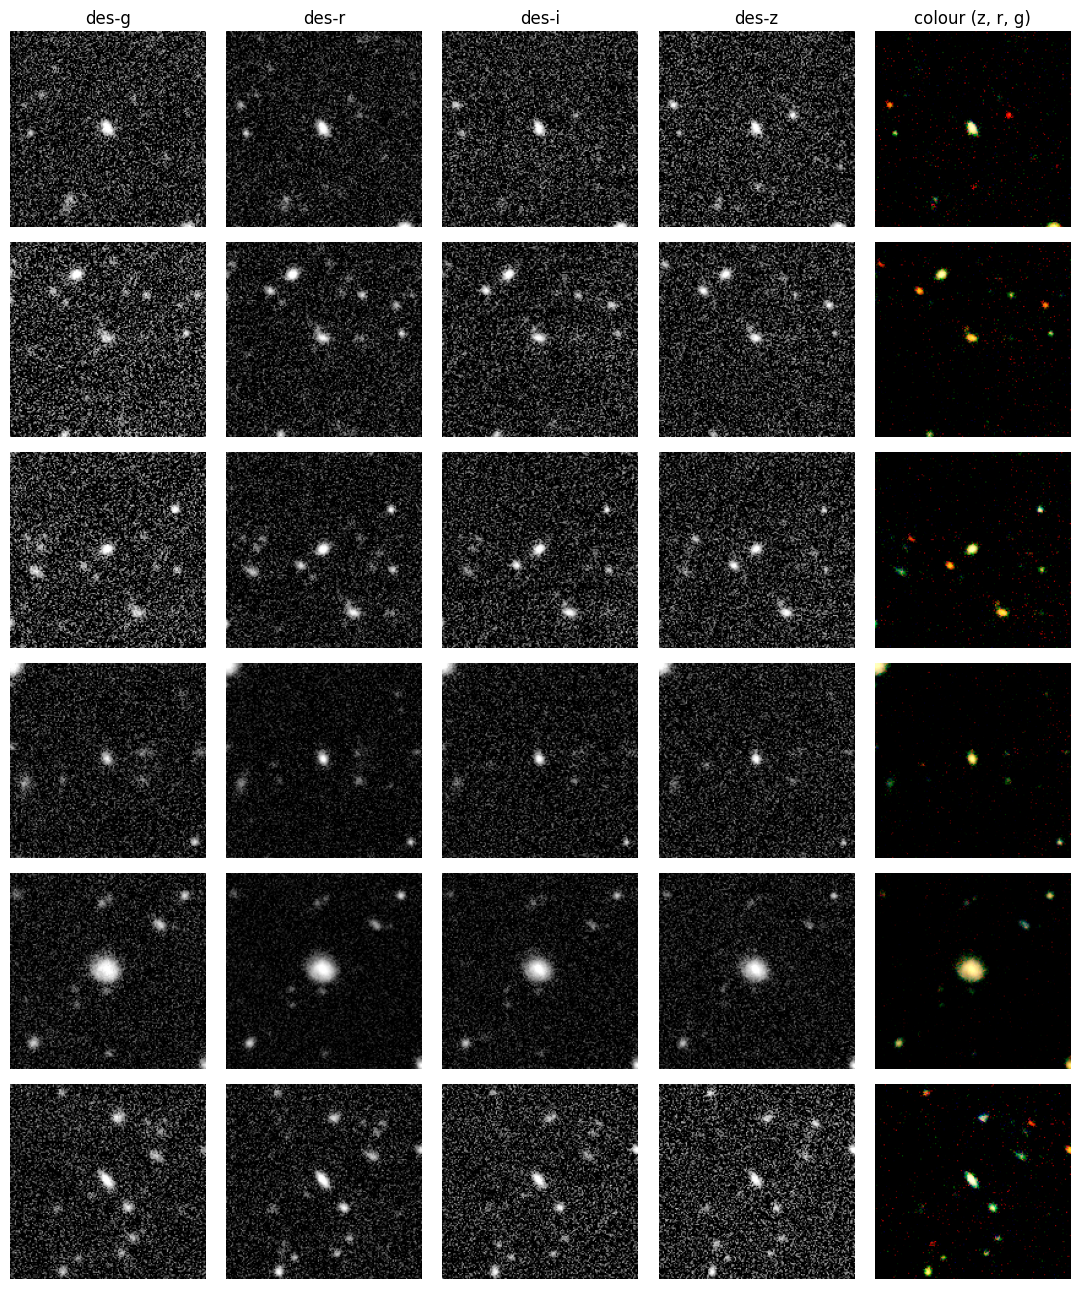

In [8]:
fig, axes = plt.subplots(6, 5, figsize=(11, 13))

for row in range(6):
    flux = examples[row]["image"]["flux"]
    for col in range(4):
        axes[row, col].imshow(stretch(flux[col]), cmap="gray")
    axes[row, 4].imshow(color_images[row])

for col, title in enumerate(bands + ["colour (z, r, g)"]):
    axes[0, col].set_title(title)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

Visual representation of the changes / modifications we made.

-> The four single-band panels use only STRETCH (no noise removal), so their sky looks grainy; the colour panel also uses REMOVE_NOISE, so its sky is clean black.
-> The g band is the noisiest because these galaxies are faint in blue light.
-> Most objects are small dots only a few pixels wide, and each cutout also contains several neighbouring sources besides the central galaxy.
-> In the colour panel most galaxies look yellow / orange -> red galaxies, matching g − r = 1.29 above.

## 5. Understand the Galaxy Zoo labels

Galaxy Zoo volunteers look at a galaxy and answer a chain of questions, for example: *Is it smooth or does it have features?* → *Is it seen edge-on?* → *Does it have spiral arms?* → *Is there a bar?*

In [9]:
gz_dataset = load_dataset("mwalmsley/gz_desi", split="train", streaming=True)
gz_dataset = gz_dataset.shuffle(seed=42, buffer_size=500)

gz_rows = list(gz_dataset.take(300))
print("Loaded", len(gz_rows), "labelled galaxies")
print("Number of columns:", len(gz_rows[0]))
print("Image size:", gz_rows[0]["image"].size)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loaded 300 labelled galaxies
Number of columns: 232
Image size: (424, 424)


Load 300 random galaxies from the Galaxy Zoo DESI dataset. These come with the volunteer votes and their own colour images (424×424 pixels).

In [10]:
columns = list(gz_rows[0].keys())
questions = sorted(set(c.split("-dr")[0] for c in columns if "-dr" in c))

for q in questions:
    answers = [c.split("_", 1)[1] for c in columns
               if c.startswith(q + "-dr5_") and not c.endswith(("_fraction", "_total-votes"))]
    print(f"{q:22s} -> {answers}")

bar                    -> ['strong', 'weak', 'no']
bulge-size             -> ['dominant', 'large', 'moderate', 'small', 'none']
disk-edge-on           -> ['yes', 'no']
edge-on-bulge          -> ['boxy', 'none', 'rounded']
has-spiral-arms        -> ['yes', 'no']
how-rounded            -> ['round', 'in-between', 'cigar-shaped']
merging                -> ['none', 'minor-disturbance', 'major-disturbance', 'merger']
smooth-or-featured     -> ['smooth', 'featured-or-disk', 'artifact']
spiral-arm-count       -> ['1', '2', '3', '4', 'more-than-4', 'cant-tell']
spiral-winding         -> ['tight', 'medium', 'loose']


Basically the decision tree -> ex : if spiral we may wanna know the spiral-arm-count and so on.

In [11]:
def count_votes(row, question, answer):
    # Each galaxy was voted on in one campaign (dr5, dr8 or dr12), so we add all three
    return sum(row.get(f"{question}-{c}_{answer}") or 0 for c in ["dr5", "dr8", "dr12"])


def vote_fraction(row, question, yes_answers, other_answers):
    yes = sum(count_votes(row, question, a) for a in yes_answers)
    no = sum(count_votes(row, question, a) for a in other_answers)
    return yes / (yes + no) if yes + no > 0 else np.nan


table = []
for r in gz_rows:
    table.append({
        "summary": r["summary"] or "no summary",
        "votes": sum(count_votes(r, "smooth-or-featured", a) for a in ["smooth", "featured-or-disk", "artifact"]),
        "smooth": vote_fraction(r, "smooth-or-featured", ["smooth"], ["featured-or-disk", "artifact"]),
        "edge_on": vote_fraction(r, "disk-edge-on", ["yes"], ["no"]),
        "spiral": vote_fraction(r, "has-spiral-arms", ["yes"], ["no"]),
        "bar": vote_fraction(r, "bar", ["yes", "strong", "weak"], ["no"]),
    })

labels = pd.DataFrame(table)
labels.head(10).round(2)

,summary,votes,smooth,edge_on,spiral,bar
0,no summary,4,0.50,0.50,1.00,1.0
1,unbarred_spiral,55,0.05,0.18,0.90,0.1
2,no summary,17,0.76,NaN,NaN,NaN
3,no summary,5,0.80,0.00,0.00,0.0
4,smooth_round,37,0.84,0.00,0.00,0.0
5,no summary,40,0.70,0.50,0.20,0.2
6,smooth_round,38,0.92,0.00,0.00,0.0
7,no summary,25,0.76,0.00,0.00,0.0
8,no summary,12,0.58,0.00,0.50,0.5
9,no summary,5,0.20,0.00,0.25,0.0


We turn the raw vote count into fractions for better analysis. -> we do not entirely rely on the summary partially because a major portion of dataset is labelled as no summary and partially because 'smooth' with 51% and 99% are a lot different.

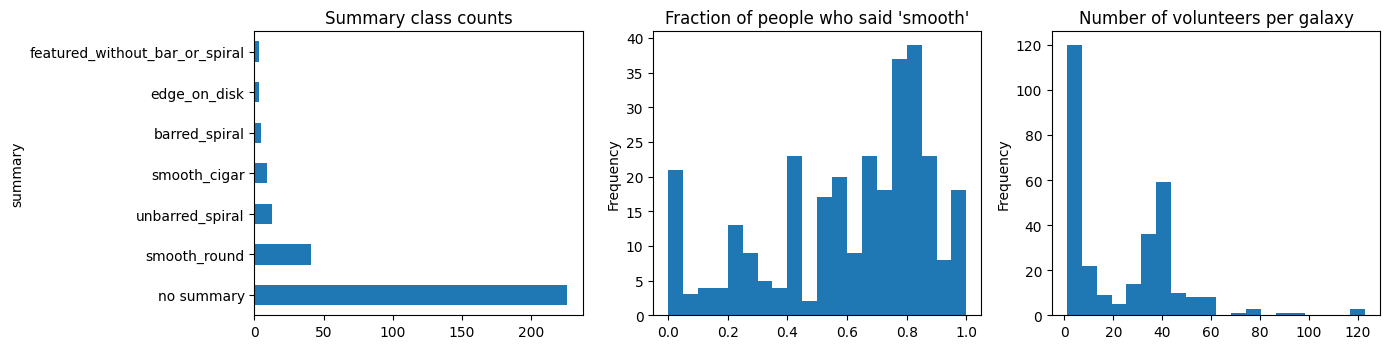

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

labels["summary"].value_counts().plot.barh(ax=axes[0])
axes[0].set_title("Summary class counts")

labels["smooth"].plot.hist(bins=20, ax=axes[1])
axes[1].set_title("Fraction of people who said 'smooth'")

labels["votes"].plot.hist(bins=20, ax=axes[2])
axes[2].set_title("Number of volunteers per galaxy")

plt.tight_layout()
plt.show()

Basic plots which help us understand the data better. -> Clearly the high percentage of no-summary tells us we cannot just use the summary column of dataset as an absolute measure.

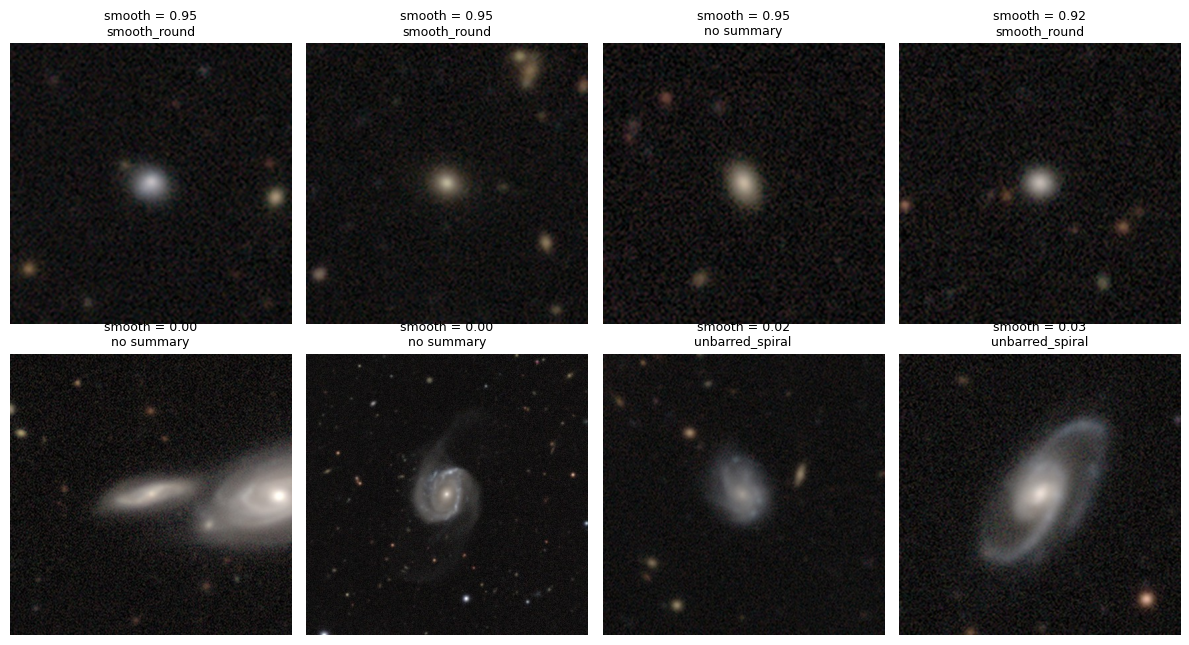

In [13]:
enough_votes = labels[labels["votes"] >= 10]
most_smooth = list(enough_votes.sort_values("smooth", ascending=False).index[:4])
most_featured = list(enough_votes.sort_values("smooth").index[:4])

fig, axes = plt.subplots(2, 4, figsize=(12, 6.5))
for ax, i in zip(axes.flat, most_smooth + most_featured):
    ax.imshow(gz_rows[i]["image"])
    ax.set_title(f"smooth = {labels.smooth[i]:.2f}\n{labels.summary[i]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

Visual representation of what a "smooth" and a "featured" galaxy looks like -> based on the percentage of votes for each.

Top row : galaxies most volunteers called smooth -> round, featureless blobs.
Bottom row : galaxies almost nobody called smooth -> spirals and discs; the bottom-left one is actually two interacting galaxies. Three of the eight have "no summary" even though the votes are very clear.

## 6. Load the pretrained DINOv2 model

In [14]:
model = AutoModel.from_pretrained("facebook/dinov2-base").to(device).eval()

print("Embedding size:", model.config.hidden_size)
print("Layers:", model.config.num_hidden_layers)
print("Attention heads:", model.config.num_attention_heads)
print("Patch size:", model.config.patch_size)
print("Parameters (millions):", round(sum(p.numel() for p in model.parameters()) / 1e6, 1))

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Embedding size: 768
Layers: 12
Attention heads: 12
Patch size: 14
Parameters (millions): 86.6


Load the pre-trained dinov2 model. 

## 7. Prepare an image for the model

In [15]:
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])


def prepare(image, size=224):
    # Resize to 224x224 and normalise the colours the way DINOv2 expects
    image = Image.fromarray((image * 255).astype(np.uint8)).resize((size, size))
    image = np.array(image) / 255.0
    image = (image - MEAN) / STD
    return torch.tensor(image.transpose(2, 0, 1), dtype=torch.float32)


x = prepare(color_images[0])
print("Input shape:", tuple(x.shape))
print("Patches:", 224 // 14, "x", 224 // 14, "=", (224 // 14) ** 2)

Input shape: (3, 224, 224)
Patches: 16 x 16 = 256


NOTE: DINOv2 needs the image size to be a multiple of 14 (its patch size). 160 isn't (160 ÷ 14 = 11.4), so we resize to 224 = 16 × 14, which gives a clean 16 × 16 = 256 patches. We also adjust the colours with the same mean and standard deviation the model was trained with, and reorder the array to (colours, height, width), which is the layout PyTorch uses.

## 8. Run the model

In [16]:
with torch.no_grad():
    output = model(pixel_values=x.unsqueeze(0).to(device))

tokens = output.last_hidden_state.cpu()
print("Output shape:", tuple(tokens.shape))

Output shape: (1, 257, 768)


Pass one galaxy thru the model

Shape -> 1 ( 1 image ) , 257 ( number of tokens in that image ) , 768 ( total numbers describing each token )

## 9. Extract the CLS token

CLS token shape: (1, 768)
First 5 values: [ 2.656  0.894  3.077  2.003 -2.269]


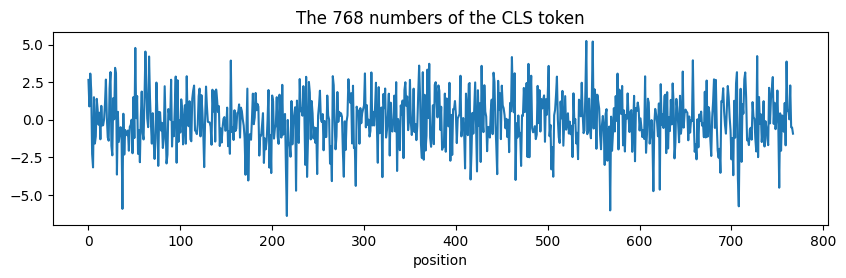

In [17]:
cls_token = tokens[:, 0, :]

print("CLS token shape:", tuple(cls_token.shape))
print("First 5 values:", cls_token[0, :5].numpy().round(3))

plt.figure(figsize=(10, 2.5))
plt.plot(cls_token[0].numpy())
plt.title("The 768 numbers of the CLS token")
plt.xlabel("position")
plt.show()

Taking a look at the CLS token -> the entire description of our image in numbers. -> we would expect similar types of galaxies to have similar CLS tokens.

## 10. Extract the patch tokens

In [18]:
patch_tokens = tokens[:, 1:, :]
print("Patch tokens shape:", tuple(patch_tokens.shape))

patch_grid = patch_tokens.reshape(1, 16, 16, 768)
print("As a 16x16 grid:", tuple(patch_grid.shape))

Patch tokens shape: (1, 256, 768)
As a 16x16 grid: (1, 16, 16, 768)


Take the other 256 tokens, one for each 14×14 square of the image, in reading order (left to right, top to bottom). We reshape them into a 16×16 grid so each vector sits at the position of its square in the picture. These describe local details, such as a spiral arm or a nearby star, rather than the whole galaxy.

## 11. Check all the shapes

In [19]:
shapes = pd.DataFrame([
    ["Input image", "(1, 3, 224, 224)", "1 image, 3 colours, 224 x 224 pixels"],
    ["Patches", "16 x 16 = 256", "each patch is 14 x 14 pixels"],
    ["Model output", str(tuple(tokens.shape)), "1 CLS + 256 patch tokens, 768 numbers each"],
    ["CLS token", str(tuple(cls_token.shape)), "summary of the whole galaxy"],
    ["Patch tokens", str(tuple(patch_grid.shape)), "one vector per patch, laid out as a grid"],
], columns=["What", "Shape", "Meaning"])
shapes

,What,Shape,Meaning
0,Input image,"(1, 3, 224, 224)","1 image, 3 colours, 224 x 224 pixels"
1,Patches,16 x 16 = 256,each patch is 14 x 14 pixels
2,Model output,"(1, 257, 768)","1 CLS + 256 patch tokens, 768 numbers each"
3,CLS token,"(1, 768)",summary of the whole galaxy
4,Patch tokens,"(1, 16, 16, 768)","one vector per patch, laid out as a grid"


Overall dimension data.

## 12. Visualise the patch grid

In [20]:
def get_tokens(images, batch_size=32):
    # Run DINOv2 on the list of images
    cls_list, patch_list = [], []
    for start in range(0, len(images), batch_size):
        batch = torch.stack([prepare(img) for img in images[start:start + batch_size]]).to(device)
        with torch.no_grad():
            out = model(pixel_values=batch).last_hidden_state.cpu().numpy()
        cls_list.append(out[:, 0])
        patch_list.append(out[:, 1:])
    return np.concatenate(cls_list), np.concatenate(patch_list)


cls_all, patches_all = get_tokens(color_images)
print("CLS tokens:", cls_all.shape)
print("Patch tokens:", patches_all.shape)

CLS tokens: (32, 768)
Patch tokens: (32, 256, 768)


Now repeating the process for all 32 galaxies

-> Extracted the CLS and patch tokens.

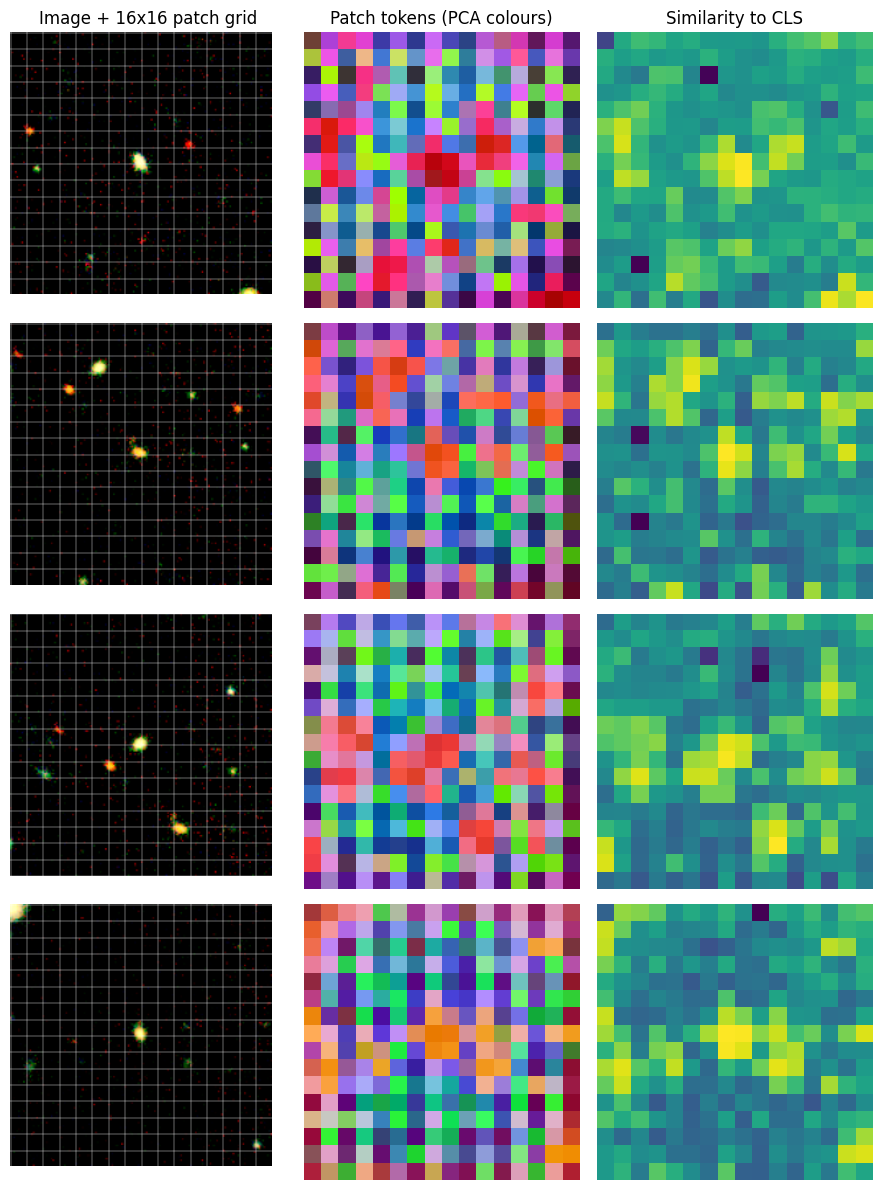

In [21]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(4, 3, figsize=(9, 12))

for row in range(4):
    # Left: the galaxy with the 16x16 patch grid drawn on top
    big = np.array(Image.fromarray((color_images[row] * 255).astype(np.uint8)).resize((224, 224)))
    axes[row, 0].imshow(big)
    for k in range(0, 225, 14):
        axes[row, 0].axhline(k, color="white", linewidth=0.3)
        axes[row, 0].axvline(k, color="white", linewidth=0.3)

    # Middle: squeeze each patch's 768 numbers down to 3 and show them as a colour
    colors = PCA(n_components=3).fit_transform(patches_all[row])
    colors = (colors - colors.min(0)) / (colors.max(0) - colors.min(0))
    axes[row, 1].imshow(colors.reshape(16, 16, 3))

    # Right: how similar each patch is to the CLS summary
    p = patches_all[row] / np.linalg.norm(patches_all[row], axis=1, keepdims=True)
    c = cls_all[row] / np.linalg.norm(cls_all[row])
    axes[row, 2].imshow((p @ c).reshape(16, 16), cmap="viridis")

axes[0, 0].set_title("Image + 16x16 patch grid")
axes[0, 1].set_title("Patch tokens (PCA colours)")
axes[0, 2].set_title("Similarity to CLS")
for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

 **Left Column:** the galaxy with the 16×16 grid of patches drawn on top. **Middle:** each patch's 768 numbers squeezed down to 3 (using PCA) and shown as a colour, so patches the model thinks are similar get similar colours. **Right:** how closely each patch matches the CLS summary; brighter means a closer match.

**What we actually see :**
- **Right (similarity to CLS) :** the yellow squares sit on or next to the bright sources, especially the central galaxy -> the CLS summary is mostly built from the patches where there is light, not from empty sky.
- **Middle (PCA colours) :** mostly random colours. A small group of similar colours shows up around the central galaxy in some rows (clearest in the last row), but the galaxy does not clearly stand out.

**Why the middle column looks random :**
- Our DESI galaxies are tiny (around 3 pixels). After resizing to 224 the central galaxy is only around 8 pixels across -> smaller than one 14x14 patch -> it covers only 1 to 4 of the 256 patches. The other around 250 patches are empty sky.
- PCA colours are rescaled to use the full colour range, so tiny differences between empty-sky patches get blown up into bright random colours.

## 13. First look at the embeddings

Finally, we check whether DINOv2's CLS tokens already "know" something about galaxy shape. We use the 300 Galaxy Zoo galaxies from step 5, because those have labels.

NOTE : these are the Galaxy Zoo images not our 160x160 DESI flux cutouts. So the results below show what DINOv2 can do on clear galaxy images; they are not produced by our own DESI preprocessing.

In [22]:
gz_images = [np.array(r["image"].convert("RGB")) / 255.0 for r in gz_rows]
gz_cls, _ = get_tokens(gz_images)
print("CLS tokens for Galaxy Zoo galaxies:", gz_cls.shape)

CLS tokens for Galaxy Zoo galaxies: (300, 768)


Here we run DINOv2 on the 300 labelled Galaxy Zoo images and keeps only their CLS tokens, giving one 768-number summary per galaxy.

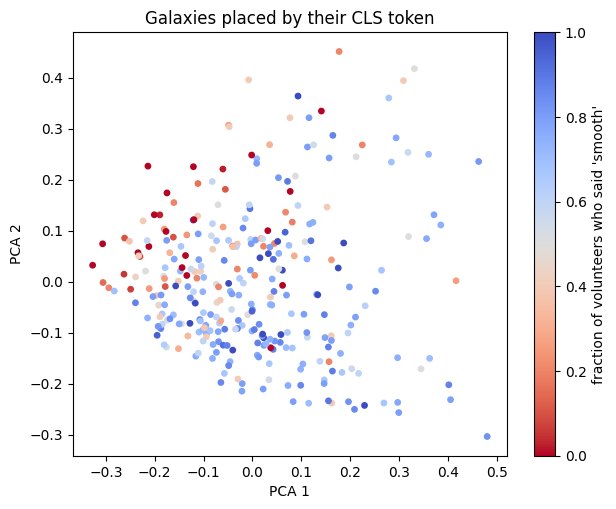

In [23]:
gz_cls_norm = gz_cls / np.linalg.norm(gz_cls, axis=1, keepdims=True)
points = PCA(n_components=2).fit_transform(gz_cls_norm)

plt.figure(figsize=(7, 5.5))
plt.scatter(points[:, 0], points[:, 1], c=labels["smooth"], cmap="coolwarm_r", s=15)
plt.colorbar(label="fraction of volunteers who said 'smooth'")
plt.title("Galaxies placed by their CLS token")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Here we squeeze each galaxy's 768 numbers down to just 2 so we can plot all galaxies as dots on a flat chart. Each dot is coloured by how "smooth" volunteers thought it was. If smooth and featured galaxies drift to different sides of the plot, the model has picked up on shape without ever being told about it.

**Result :** featured galaxies (red dots) gather in the upper-left, smooth galaxies (blue dots) drift towards the lower-right, with overlap in the middle -> DINOv2 separates smooth from featured galaxies even though it was never told what they are.

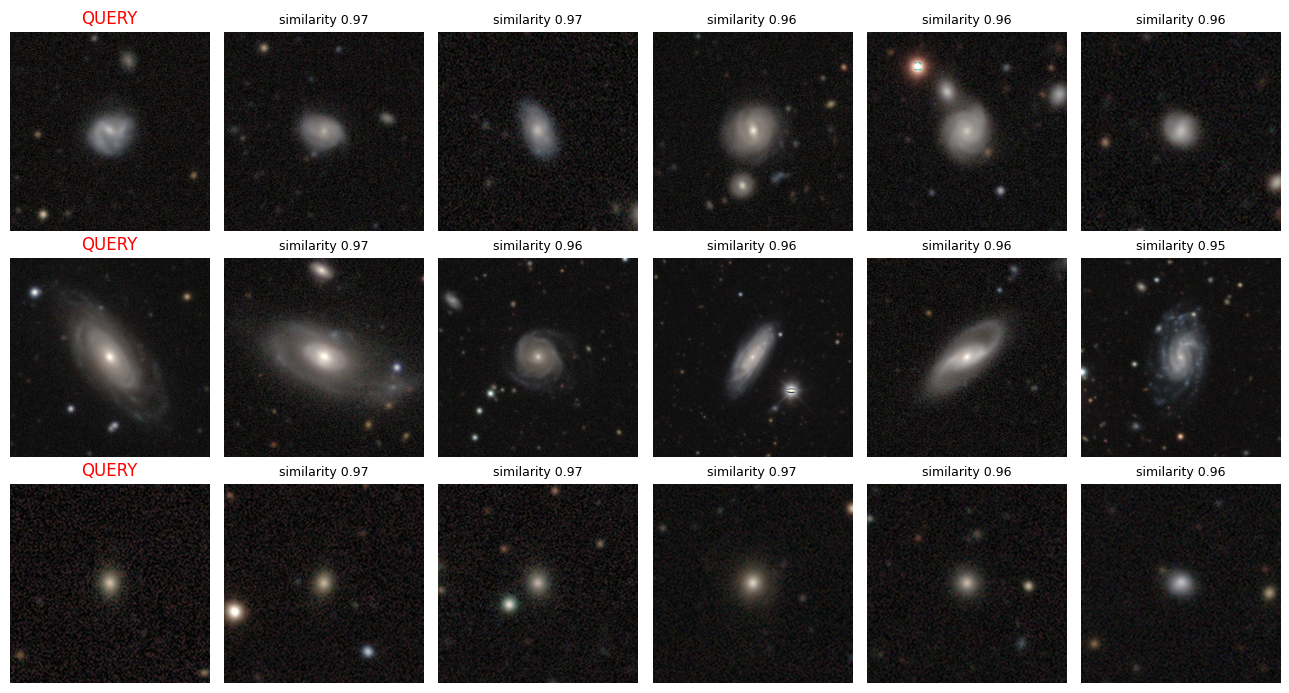

In [24]:
similarity = gz_cls_norm @ gz_cls_norm.T
np.fill_diagonal(similarity, -1)

fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for row, query in enumerate([0, 1, 2]):
    closest = np.argsort(-similarity[query])[:5]

    axes[row, 0].imshow(gz_images[query])
    axes[row, 0].set_title("QUERY", color="red")
    for col, j in enumerate(closest, start=1):
        axes[row, col].imshow(gz_images[j])
        axes[row, col].set_title(f"similarity {similarity[query, j]:.2f}", fontsize=9)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

A mini image search. For 3 galaxies (red "QUERY" on the left) we find the 5 other galaxies with the most similar CLS tokens. If the model is doing a good job, the matches should look like the query: spirals next to spirals, round blobs next to round blobs.

**Result :**
- Row 2 : a large spiral query -> all 5 matches are spirals.
- Row 3 : a small round smooth galaxy -> all 5 matches are small round blobs.
- Row 1 : a small galaxy with faint arms -> matches have a similar size and brightness but are not all spirals -> for small galaxies, apparent size and brightness matter more than fine details.
- All similarity scores are between 0.95 and 0.97 -> every image is "dark sky + a galaxy in the middle", so all CLS tokens point in roughly the same direction; the useful differences are in the last few hundredths.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

use = (labels["votes"] >= 10) & labels["smooth"].notna()
X = gz_cls[use.values]
y = (labels.loc[use, "smooth"] > 0.5).astype(int).values

classifier = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.1))
scores = cross_val_score(classifier, X, y, cv=5)

print("Galaxies used:", len(y), "| smooth:", y.sum(), "| featured:", len(y) - y.sum())
print("Accuracy:", round(scores.mean(), 3))
print("Accuracy from always guessing the most common class:", round(max(y.mean(), 1 - y.mean()), 3))

Galaxies used: 169 | smooth: 125 | featured: 44
Accuracy: 0.847
Accuracy from always guessing the most common class: 0.74


 A quick test: can a very simple classifier tell **smooth** from **featured** galaxies using only the CLS tokens? We train it on part of the data and test it on the rest, five times over (*cross-validation*). If its accuracy beats "always guess the most common class", the CLS tokens carry real information about galaxy shape. Note that only this small classifier is trained; DINOv2 itself is never changed.

**Result :** 169 galaxies with ≥ 10 votes (125 smooth, 44 featured). Accuracy = **84.7%** vs **74%** for always guessing "smooth" -> about 11 points better than guessing -> the frozen CLS tokens carry real information about galaxy shape. (Small sample, so the exact number will vary a little.)

## Summary

- DESI galaxy images come as 4 filters (g, r, i, z) of 160×160 pixels. We combined three of them into a colour image.
- Galaxy Zoo labels are volunteer vote counts from a chain of questions, not single answers.
- DINOv2 cuts a 224×224 image into 256 patches of 14×14 pixels and returns 257 tokens × 768 numbers:
  - CLS token (1 × 768): a summary of the whole galaxy
  - Patch tokens (256 × 768): one description per small square of the image
- We used DINOv2 without training it.

**Results**
- CLS similarity maps highlight the bright sources, especially the central galaxy.
- In PCA of the CLS tokens, smooth and featured Galaxy Zoo galaxies drift to different sides.
- Nearest-neighbour search returns spirals for a spiral and round blobs for a round blob.
- A simple classifier on the CLS tokens reaches 84.7% (smooth vs featured) vs 74% for guessing.

**Limitations**
- DINOv2 learned from everyday photos, not telescope images.
- We dropped the i band to make a 3-colour image.
- Galaxy Zoo votes can be noisy.
- The images from step 2 and the labels from step 5 are not matched up yet.
- Our first 32 DESI galaxies are tiny (around 3 pixels), so each covers only a few of the 256 patches -> the patch-level plots are dominated by empty sky.
- The good embedding results (step 13) come from the Galaxy Zoo images, which show bigger and brighter galaxies than our DESI cutouts.